In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("vgchartz-2024.csv")

In [ ]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17/09/2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18/11/2014,03/01/2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28/10/2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17/09/2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06/11/2015,14/01/2018


In [ ]:
df.shape

(64016, 14)

In [ ]:
df.size

896224

In [ ]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    format="%d/%m/%Y",
    errors="coerce"
)

In [ ]:
df["last_update"] = pd.to_datetime(
    df["last_update"],
    errors="coerce"
)

In [ ]:
df['year'] = df['release_date'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   img           64016 non-null  object        
 1   title         64016 non-null  object        
 2   console       64016 non-null  object        
 3   genre         64016 non-null  object        
 4   publisher     64016 non-null  object        
 5   developer     63999 non-null  object        
 6   critic_score  6678 non-null   float64       
 7   total_sales   18922 non-null  float64       
 8   na_sales      12637 non-null  float64       
 9   jp_sales      6726 non-null   float64       
 10  pal_sales     12824 non-null  float64       
 11  other_sales   15128 non-null  float64       
 12  release_date  56965 non-null  datetime64[ns]
 13  last_update   56965 non-null  datetime64[ns]
 14  year          56965 non-null  float64       
dtypes: datetime64[ns](2), float64(7), ob

In [ ]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,year
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000,56965,56965,56965.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041,2006-11-14 06:33:03.491617792,2006-11-14 06:33:03.491617792,2006.359572
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971-12-03 00:00:00,1971-12-03 00:00:00,1971.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000,2001-03-28 00:00:00,2001-03-28 00:00:00,2001.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000,2008-09-16 00:00:00,2008-09-16 00:00:00,2008.000000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000,2012-12-27 00:00:00,2012-12-27 00:00:00,2012.000000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024-12-31 00:00:00,2024-12-31 00:00:00,2024.000000
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643,NaN,NaN,8.617813


In [ ]:
df.isna()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,year
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,False,False,False,False,False,False,True,True,True,True,True,True,False,False,False
64012,False,False,False,False,False,False,True,True,True,True,True,True,False,False,False
64013,False,False,False,False,False,False,True,True,True,True,True,True,False,False,False
64014,False,False,False,False,False,False,True,True,True,True,True,True,False,False,False


In [ ]:
df.isnull().sum()

,0
img,0
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,57338
total_sales,45094
na_sales,51379
jp_sales,57290


In [ ]:
col = [
    'developer',
    'release_date',
    'last_update'
]

for i in col:
    df[i] = df[i].fillna('Unknown')

In [ ]:
cols = [
    'total_sales',
    'na_sales',
    'jp_sales',
    'pal_sales',
    'other_sales',
    'critic_score'
]

for j in cols:
    df[j] = df[j].fillna(df[j].median())

In [ ]:
print(df.duplicated().sum())


0


In [ ]:
df.isnull().sum()

,0
img,0
title,0
console,0
genre,0
publisher,0
developer,0
critic_score,0
total_sales,0
na_sales,0
jp_sales,0


In [ ]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
count,64016.000000,64016.000000,64016.000000,64016.000000,64016.000000,64016.000000,56965.000000
mean,0.753220,0.187722,0.148572,0.046544,0.061930,0.017808,2006.359572
std,2.256713,0.451266,0.227252,0.057952,0.181117,0.063143,8.617813
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971.000000
25%,0.000000,0.120000,0.120000,0.040000,0.040000,0.010000,2001.000000
50%,0.000000,0.120000,0.120000,0.040000,0.040000,0.010000,2008.000000
75%,0.000000,0.120000,0.120000,0.040000,0.040000,0.010000,2012.000000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024.000000


/tmp/ipykernel_2360/965225026.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


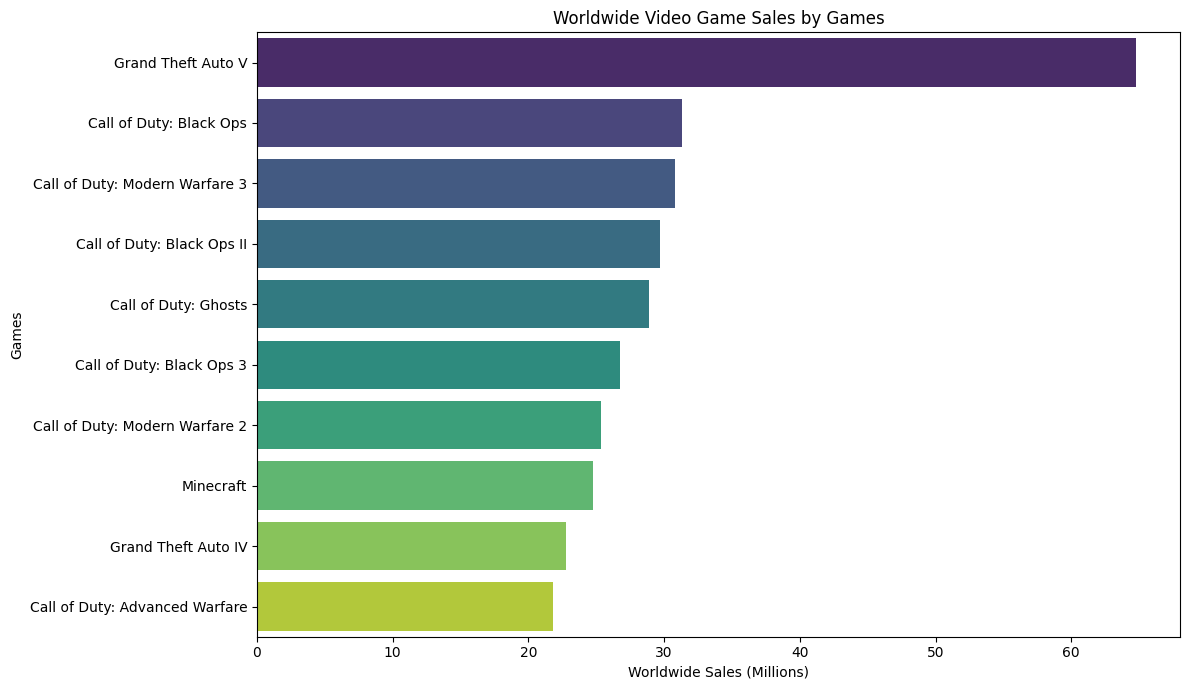

In [ ]:
plt.figure(figsize=(12, 7))


games_sales = df.groupby("title")["total_sales"].sum().sort_values(ascending=False).head(10)


sns.barplot(
    x=games_sales.values,
    y=games_sales.index,
    palette="viridis"
)


plt.xlabel("Worldwide Sales (Millions)")
plt.ylabel("Games")
plt.title("Worldwide Video Game Sales by Games")

plt.tight_layout()
plt.show()


Top-Selling Video Games (Worldwide)

* *Grand Theft Auto V* leads global sales with **~64.8M units**, exceeding the second-ranked title (*Call of Duty: Black Ops* at **~31.3M**) by more than 2x.

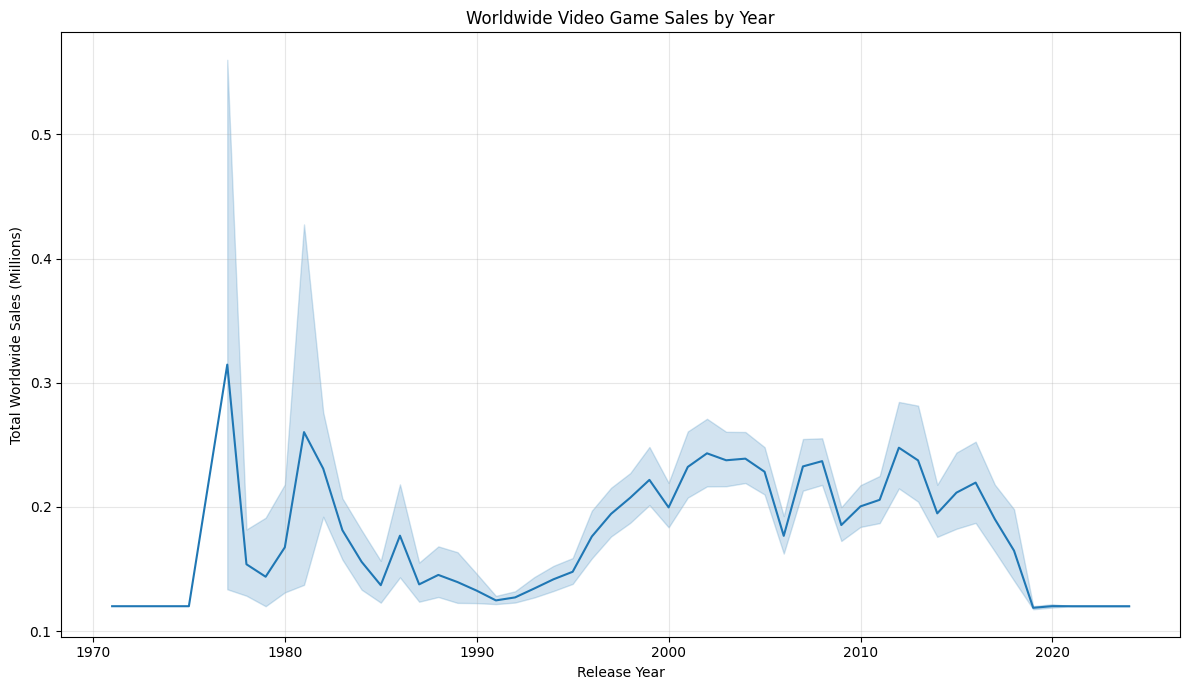

In [ ]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    x='year',
    y='total_sales',
    data=df,
)

plt.xlabel("Release Year")
plt.ylabel("Total Worldwide Sales (Millions)")
plt.title("Worldwide Video Game Sales by Year")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Video Game Sales by Release Year**

* **Early Sample Volatility (1976–1982):** High average sales peaks and wide confidence intervals reflect low title counts with isolated blockbuster hits in the early arcade/home console era.
* **Sustained Commercial Peak (1996–2016):** Average sales per title consistently held between **0.20M – 0.25M units**, driven by the mass adoption of 5th to 8th generation home consoles.
* **Recent Plateau (Post-2018):** The flattening of average sales at **~0.12M** illustrates the effect of median imputation for newer titles lacking recorded physical retail sales.

/tmp/ipykernel_2360/130811588.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


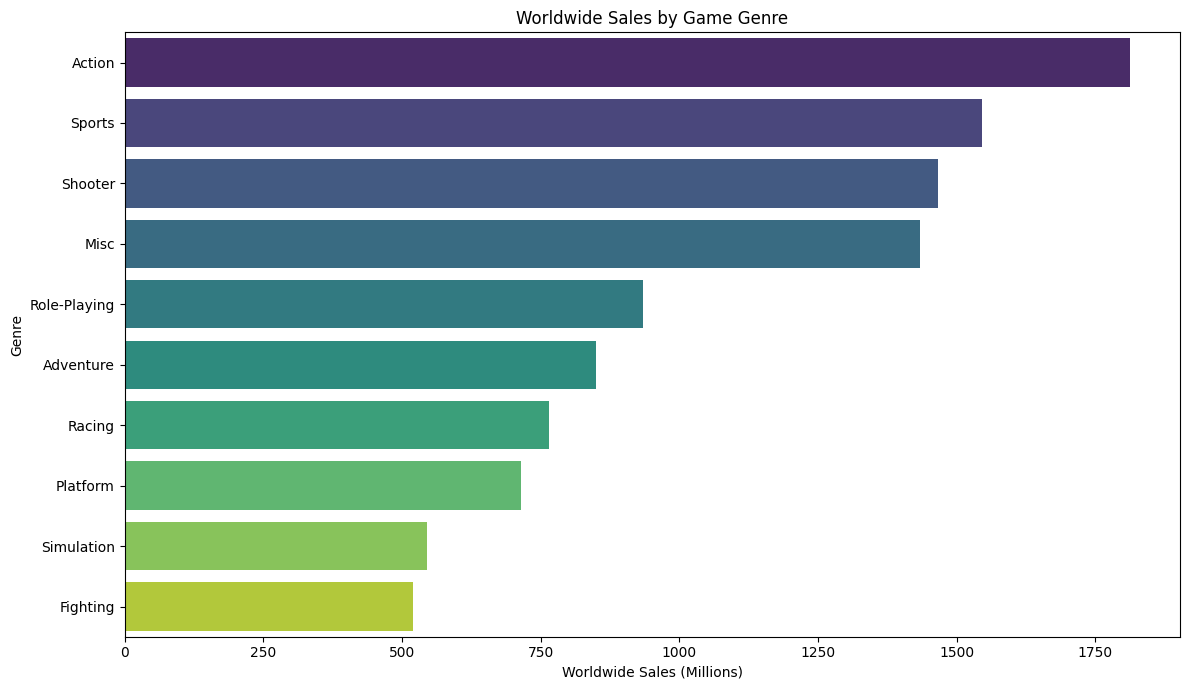

In [ ]:
plt.figure(figsize=(12, 7))

genre_sales = df.groupby("genre")["total_sales"].sum().sort_values(ascending=False).head(10)


sns.barplot(
    x=genre_sales.values,
    y=genre_sales.index,
    palette="viridis"
)

plt.xlabel("Worldwide Sales (Millions)")
plt.ylabel("Genre")
plt.title("Worldwide Sales by Game Genre")

plt.tight_layout()
plt.show()

**Global Sales by Game Genre**

* **Action** is the highest-grossing genre globally with **~1,810M units**, outperforming second-place Sports by ~260M units.

/tmp/ipykernel_2360/3852459255.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


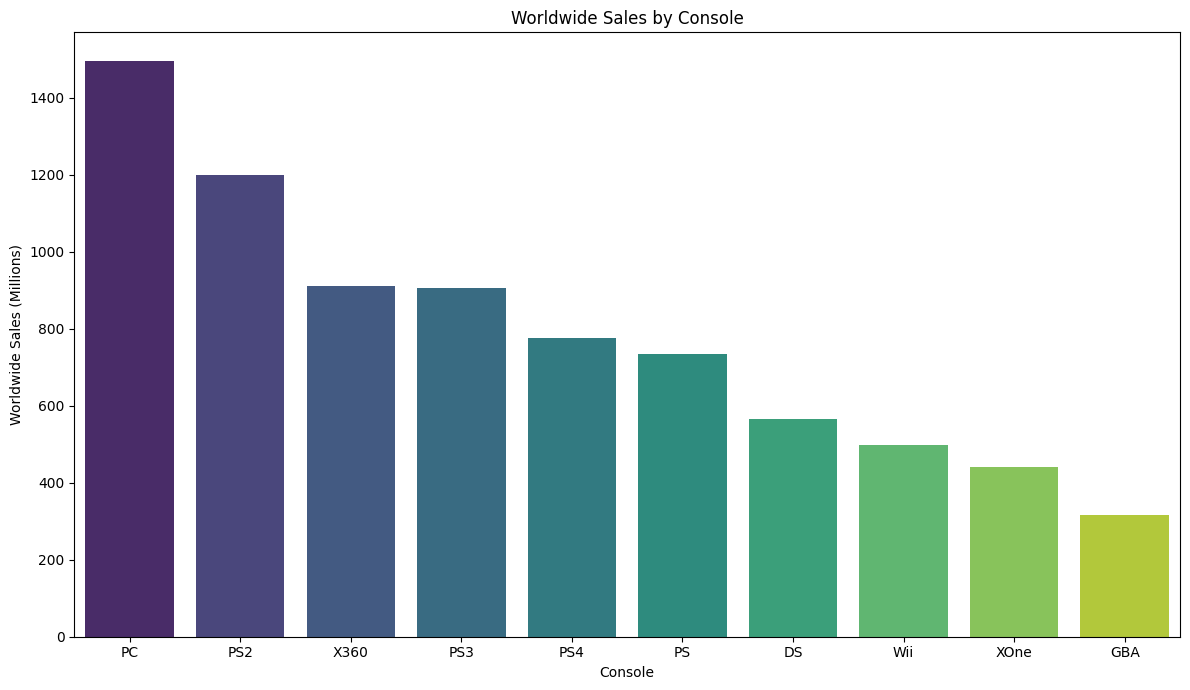

In [ ]:
plt.figure(figsize=(12, 7))


console_sales = df.groupby("console")["total_sales"].sum().sort_values(ascending=False).head(10)


sns.barplot(
    x=console_sales.index,
    y=console_sales.values,
    palette="viridis"
)

plt.xlabel("Console")
plt.ylabel("Worldwide Sales (Millions)")
plt.title("Worldwide Sales by Console")

plt.tight_layout()
plt.show()

**Worldwide Sales by Console**

* **PC** holds the highest aggregate game sales at **~1,500M units**, driven by decades of backwards compatibility and an expansive global catalog.

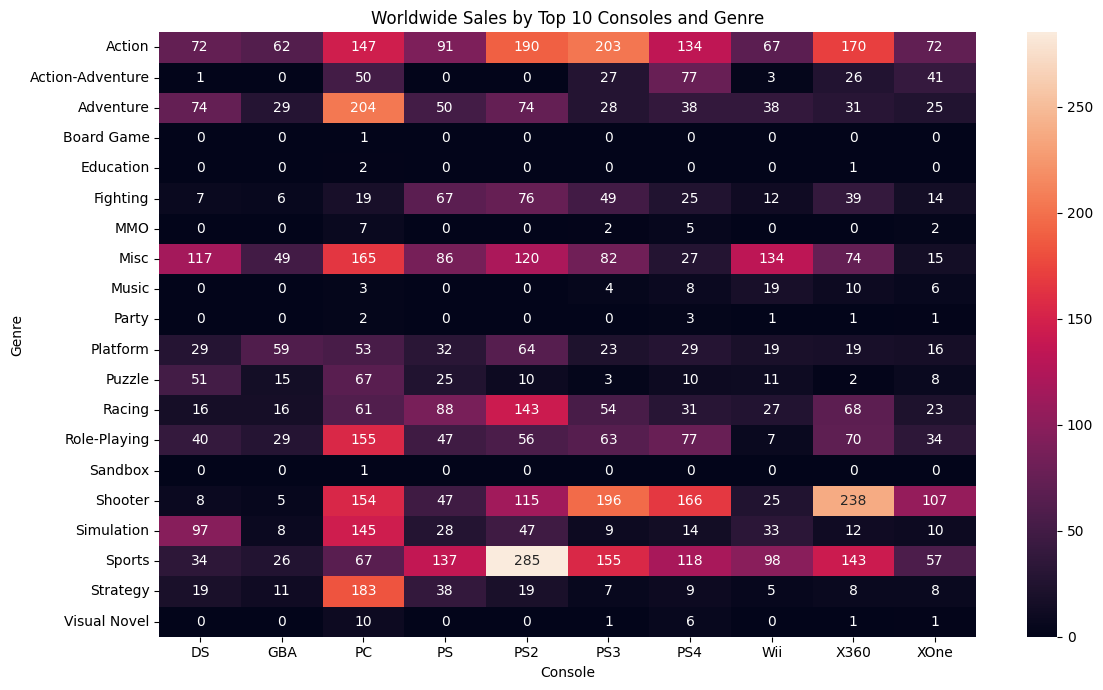

In [ ]:
top_consoles = (
    df.groupby("console")["total_sales"]
      .sum()
      .nlargest(10)
      .index
)

console_genre = (
    df[df["console"].isin(top_consoles)]
    .pivot_table(
        index="genre",
        columns="console",
        values="total_sales",
        aggfunc="sum",
        fill_value=0
    )
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    console_genre,
    annot=True,
    fmt=".0f"
)

plt.xlabel("Console")
plt.ylabel("Genre")
plt.title("Worldwide Sales by Top 10 Consoles and Genre")

plt.tight_layout()
plt.show()

**Console and Genre Heatmap Synergies**

* **Highest Peak:** **Sports** on the **PS2** generated **285 million** unit sales, the highest single platform-genre combination, driven by widespread mainstream adoption.
* **Xbox's Shooter Dominance:** The **Xbox 360** is heavily defined by the **Shooter** genre (**238M**), confirming its status as the leading platform for FPS and third-person shooter titles.
* **PC Niche Strengths:** **PC** sales aggressively favor **Adventure (204M)** and **Strategy (183M)**, diverging from the Action/Shooter trends that dominate traditional living-room consoles.
* **Modern Console Pillars:** The modern console landscape (PS3, PS4, Xbox 360) is overwhelmingly sustained by the **Action** and **Shooter** categories.

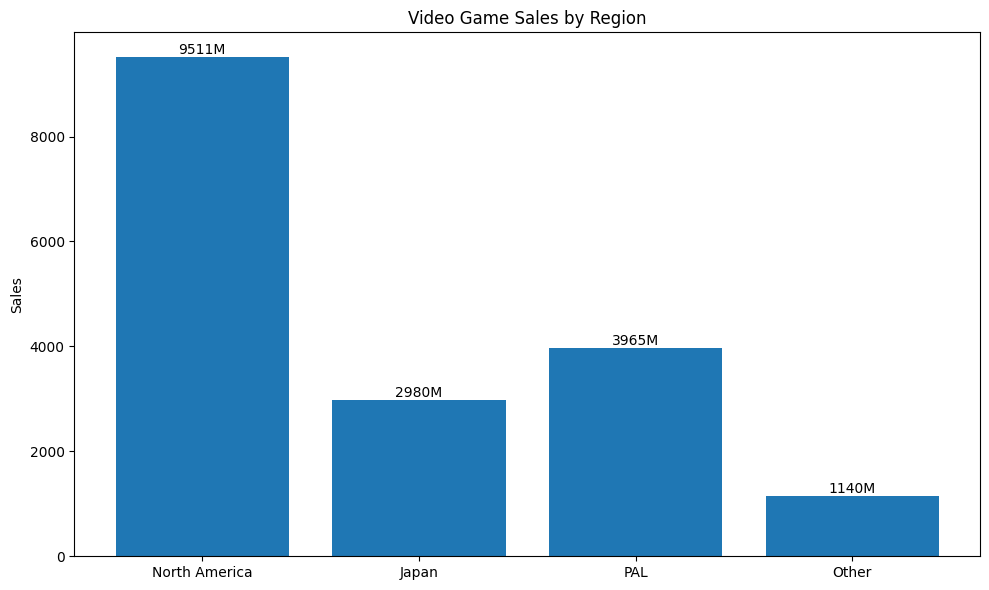

In [ ]:
regional_sales = df[
    ["na_sales", "jp_sales", "pal_sales", "other_sales"]
].sum()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    ["North America", "Japan", "PAL", "Other"],
    regional_sales.values
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.0f}M",
        ha="center",
        va="bottom"
    )

plt.ylabel("Sales")
plt.title("Video Game Sales by Region")

plt.tight_layout()
plt.show()

**Regional Sales Distribution**

* **North American Dominance:** North America leads the global market with **9,511 million units sold**, representing a staggering market share that outright exceeds the combined physical sales of PAL, Japan, and all other regions.
* **Western Market Concentration:** The combination of North America and PAL territories constitutes the overwhelming majority of historical game sales, making Western market penetration critical for AAA franchise viability.
* **High-Density Japanese Market:** Despite a much smaller population than the NA or PAL regions, Japan maintains a massive sales volume (**2,980 million units**), highlighting its highly concentrated and historically robust console gaming culture.

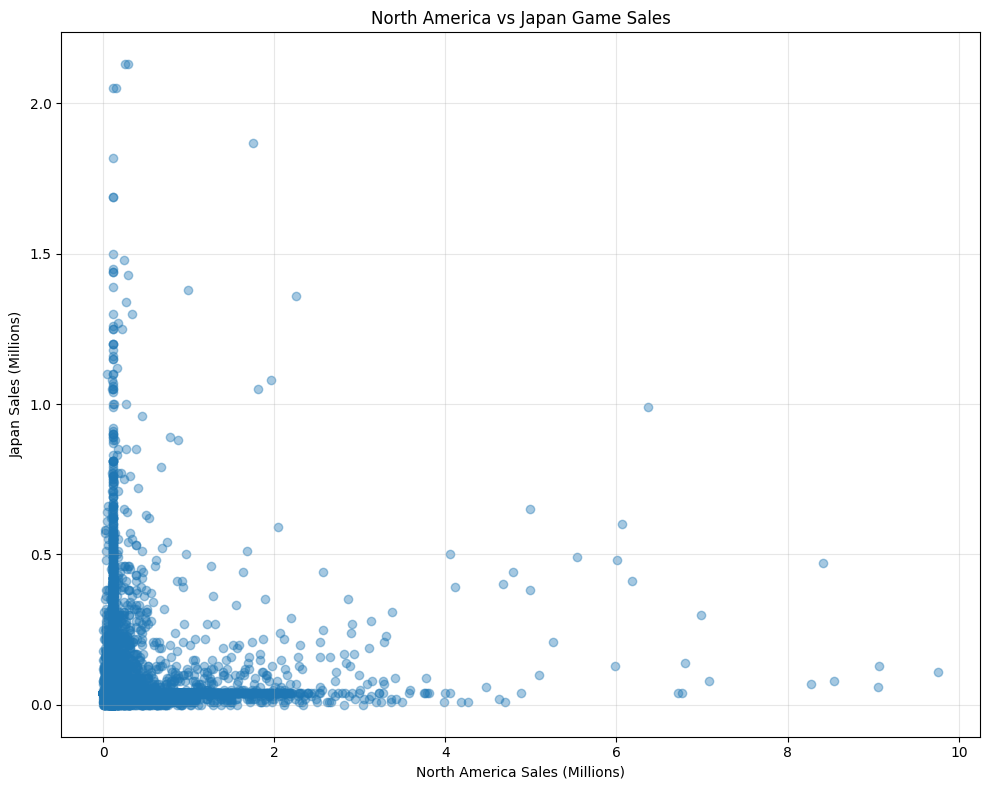

In [ ]:
regional = df[
    ["title", "na_sales", "jp_sales"]
].dropna()

plt.figure(figsize=(10, 8))

plt.scatter(
    regional["na_sales"],
    regional["jp_sales"],
    alpha=0.4
)

plt.xlabel("North America Sales (Millions)")
plt.ylabel("Japan Sales (Millions)")
plt.title("North America vs Japan Game Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### North America vs. Japan Sales

* **Regional Market Polarisation:** The distinct **L-shaped distribution** demonstrates that gaming preferences between North America and Japan are heavily decoupled, resulting in a near-zero linear correlation.

**Key Findings**

Based on the exploratory data analysis and visualizations, we can draw the following primary conclusions regarding the video game market:

* **Dominant Genres:** The *Action* and *Shooter* categories represent the most lucrative segments in the industry, driving the highest volume of global sales.
* **Platform Dominance:** PlayStation ecosystems (notably the PS2, PS3, and PS4) alongside the Xbox 360 have historically captured the largest share of the console market.
* **Top-Performing Titles:** Blockbuster AAA franchises, specifically *Grand Theft Auto V* and the *Call of Duty* series, consistently command the highest all-time sales figures.
* **Market Synergies:** The heatmap analysis reveals distinct synergies between specific platforms and genres, demonstrating that Action and Shooter games achieve exceptionally high sales concentrations on the PS3, PS4, and Xbox 360 platforms.